# Análisis de la actividad de los clientes - Proyecto Sakila

## 1.Contexto del proyecto

En este proyecto se trabaja con un archivo CSV previamente limpiado, unión( **JOIN** ) y exportado de datos en SQL. 
Se usó la base de datos **Sakila**.
Las tablas que se tratarón fueron: 

- customer
- address
- city
- country
- rental
- payment

El objetivo de la integración fué poder obtener un dataset consolidado que combine información sobre clientes,localizaciones,alquileres y pagos. En siguientes puntos se usará Python para realizar la carga como dataframe y poder realizar un análisis completo sobre los datos y poder visualizarlos.
En este notebook se continuará el flujo de trabajo iniciado en SQL, centrándose en la exploración de datos y análisis de los mismos.

## 2. Importación de librerías

In [2345]:
#Importación de librerías
import pandas as pd # Para manipulación de datos
import numpy as np # Para cálculos numéricos
import plotly as pl # Para visualización interactiva
import seaborn as sns # Para visualización estadística
import missingno as msno # Para visualización de datos faltantes
import matplotlib.pyplot as plt # Para visualización de datos
import geopandas as gpd # Para conjunto de datos geoespaciales

## 3. Carga de datos

Se procede a la carga del dataset y se convierte en dataframe para poder trabajar con los datos

In [2346]:
# Carga del dataset a dataframe y vistado previo antes de trabajar en el dataframe
df = pd.read_csv('../csv_files/actividad_clientes.csv')
df.head(5)

,customer_id,customer_name,city,country,rental_date,return_date,rental_duration,amount
0,1,mary smith,sasebo,japan,2005-05-25 11:30:37,2005-06-03 12:00:37,9,2.99
1,1,mary smith,sasebo,japan,2005-05-28 10:35:23,2005-06-03 06:32:23,6,0.99
2,1,mary smith,sasebo,japan,2005-06-15 00:54:12,2005-06-23 02:42:12,8,5.99
3,1,mary smith,sasebo,japan,2005-06-15 18:02:53,2005-06-19 15:54:53,4,0.99
4,1,mary smith,sasebo,japan,2005-06-15 21:08:46,2005-06-25 02:26:46,10,9.99


## 4.Validación y limpieza del dataset

En esta sección se revisará si el dataset exportado desde SQL presenta errores o inconsistencias que **no** hayan sido detectados en la limpieza previa. Para ello veremos las propiedades de la tabla

In [2347]:
#Conteo de datos en cada columna
df.count()

customer_id        15861
customer_name      15861
city               15861
country            15861
rental_date        15861
return_date        15861
rental_duration    15861
amount             15861
dtype: int64

Observamos que no hay valores nulos en el dataframe. Aun así, realizaremos un conteo para confirmalo y verificar si existe algún valor faltante en alguna columna en específico

In [2348]:
# Conteo de valores nulos por columna
df.isnull().sum().sort_values(ascending=False)

customer_id        0
customer_name      0
city               0
country            0
rental_date        0
return_date        0
rental_duration    0
amount             0
dtype: int64

<Axes: >

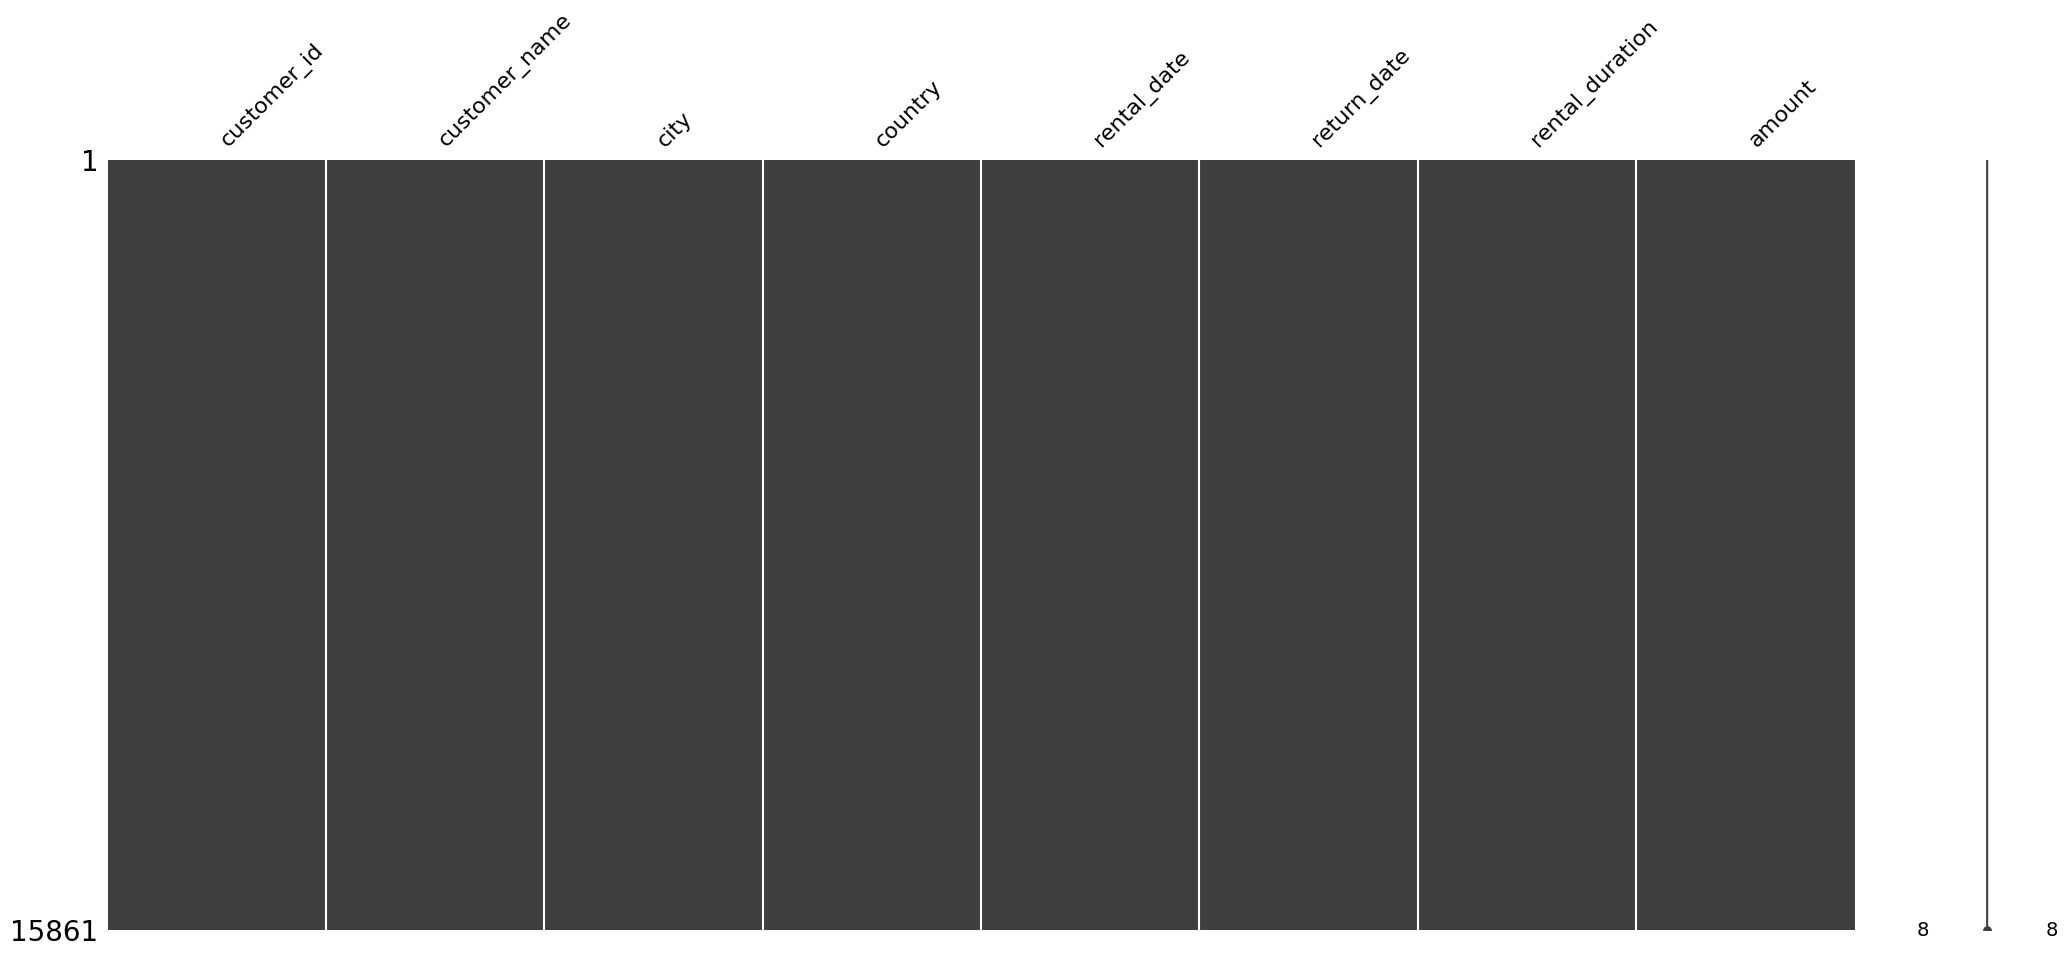

In [2349]:
# Muestra visual de los datos faltantes. En este caso no tenemos filas nulas
# pero son útiles estas gráficas a la hora de mostrar núlos ya que podría darse algún patrón
# que haga que por x o y motivo existan en la tabla
msno.matrix(df)

Se comproborá si el dataframe contiene filas duplicadas, ya que estos registros podrían afectar en la calidad del análisis

In [2350]:
# Copia en una variable los posibles valores duplicados
duplicados = df[df.duplicated()]
duplicados.count()

customer_id        0
customer_name      0
city               0
country            0
rental_date        0
return_date        0
rental_duration    0
amount             0
dtype: int64

No existen valores duplicados en el dataframe.
A continuación se procederá a revisar el tipo de dato de cada columna,y en caso necesario, realizar los cambios de tipado correspondiente para asegurar un análisis adecuado. Para ello, se creará una copia del dataframe sobre la que se aplicarán los cambios de tipado, manteniendo intacto el dataset original.

In [2351]:
actividad_clientes_clean_csv = df.copy()
actividad_clientes_clean_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      15861 non-null  int64  
 1   customer_name    15861 non-null  object 
 2   city             15861 non-null  object 
 3   country          15861 non-null  object 
 4   rental_date      15861 non-null  object 
 5   return_date      15861 non-null  object 
 6   rental_duration  15861 non-null  int64  
 7   amount           15861 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 991.4+ KB


In [2352]:
# Según el tipo de dato de se crearán listas para ello
cols_fecha = ['rental_date','return_date']
cols_string = ['customer_name','city','country']

# Cambio de las columnas de fecha en formato datetime
actividad_clientes_clean_csv[cols_fecha] = actividad_clientes_clean_csv[cols_fecha].apply(pd.to_datetime)

# Cambio de las columnas de object a string
actividad_clientes_clean_csv[cols_string] = actividad_clientes_clean_csv[cols_string].astype('string')

In [2353]:
actividad_clientes_clean_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      15861 non-null  int64         
 1   customer_name    15861 non-null  string        
 2   city             15861 non-null  string        
 3   country          15861 non-null  string        
 4   rental_date      15861 non-null  datetime64[ns]
 5   return_date      15861 non-null  datetime64[ns]
 6   rental_duration  15861 non-null  int64         
 7   amount           15861 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(2), string(3)
memory usage: 991.4 KB


A continuación se analizarán los posibles outliers presentes en el dataframe, con el objetivo de identificar valores atípicos que puedan influir en los análisis posteriores. Se realizará con la columna **rental_duration** y **amount**

**Columna: rental_duration**

In [2354]:
# Cálculo de outliers en la columna rental_duration

# Cálculo del primer y tercer cuartil
# Conjunto de datos separando el 25% más bajo y 25% más alto de los datos
q1 = actividad_clientes_clean_csv['rental_duration'].quantile(0.25)
q3 = actividad_clientes_clean_csv['rental_duration'].quantile(0.75)

# Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

# Límites para detectar outliers
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Filtrado de outliers
outliers = actividad_clientes_clean_csv[(actividad_clientes_clean_csv['rental_duration'] < lower_bound) | actividad_clientes_clean_csv['rental_duration'] > upper_bound]
n_outliers = len(outliers)

print('Posibles outliers en la columna rental_duration')
print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'outliers encontrados: {n_outliers}')


Posibles outliers en la columna rental_duration
lower_bound: -3.0
upper_bound: 13.0
Q1: 3.0
Q3: 7.0
IQR: 4.0
outliers encontrados: 0


El límite inferior obtenido mediante el método IQR es negativo. Dado que 'rental_duration' representas días de alquiler, no es posible tener valores negativos. Por tanto, el límite inferior se ajustará a 0 para garantizar un análisis coherente.

In [2355]:
lower_bound = 0.0

A continuación se muestra un bloxpot de **rental_duration** con el fin de visualizar su distribución. Aunque como hemos visto anteriormente no se han encontrado outliers

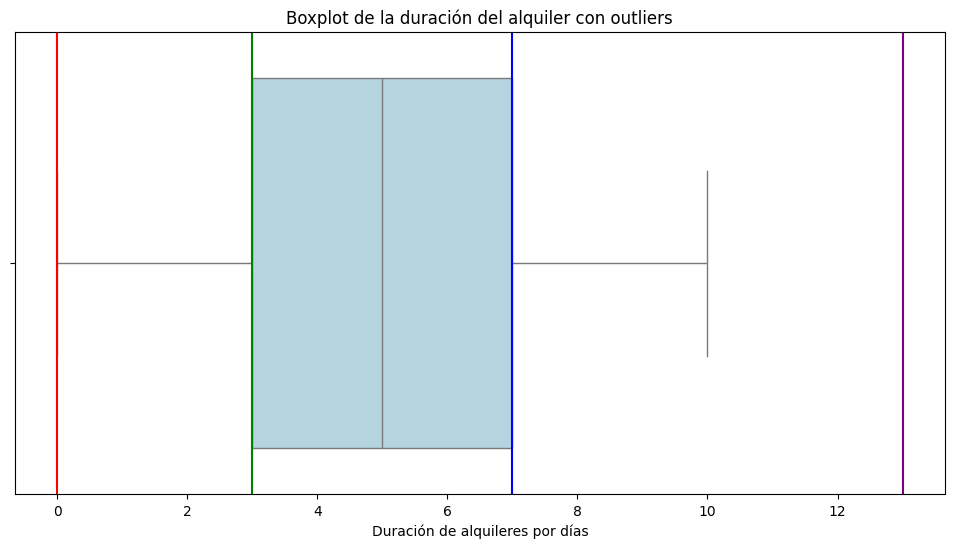

In [2356]:
plt.figure(figsize=(12,6))
# Visualización de outliers en rental_duration
sns.boxplot(x=actividad_clientes_clean_csv['rental_duration'],color='lightblue')
plt.axvline(q1,color='green',label='Q1')
plt.axvline(q3,color='blue',label='Q3')
plt.axvline(lower_bound,color='red',label='Lower bound')
plt.axvline(upper_bound,color='purple',label='Upper bound')

plt.title('Boxplot de la duración del alquiler con outliers')
plt.xlabel('Duración de alquileres por días')
plt.show()

No se encontraron en la variable **rental_duration**. Tras ajustar el límite inferior a 0 y obtener un límite superior de 13, se observa una distribución consistente y no presenta valores extremos.

El primer cuartil indica que el 25% de los alquileres tiene una duración de hasta 3 días . El tercer cuartil muestra que el 75% de las duraciones se sitúan por debajo de 7 días. Por tanto, la mayor concentración de valores se encuentra en 3 y 7 días, que corresponde el rango IQR.

A continuación se muestra un gráfico de densidad para visualizar la distribución de **rental_duration** y observar con mayor precisión donde se concentran sus valores

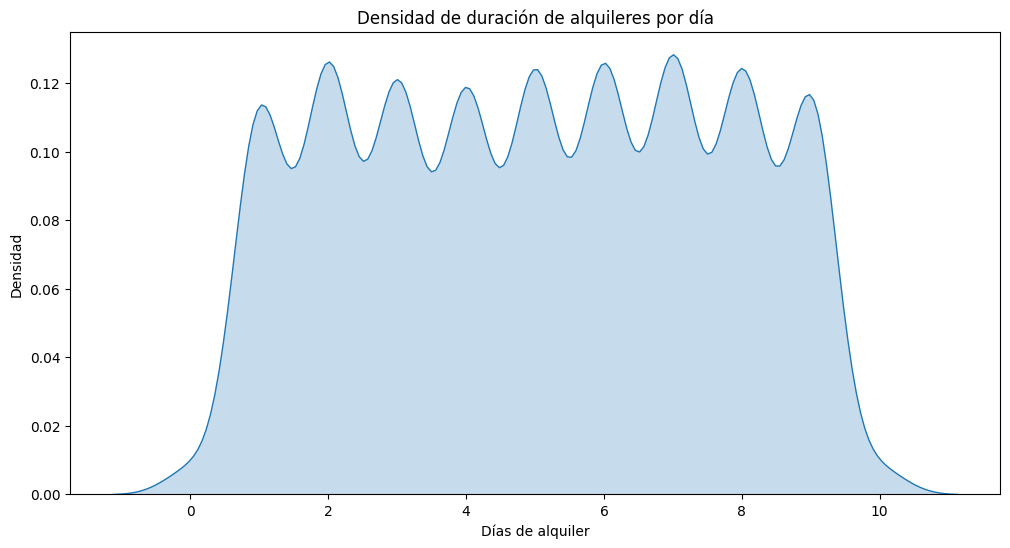

In [2357]:
plt.figure(figsize=(12,6))
sns.kdeplot(actividad_clientes_clean_csv['rental_duration'],fill=True)
plt.title(f'Densidad de duración de alquileres por día')
plt.xlabel('Días de alquiler')
plt.ylabel('Densidad')
plt.show()


En el gráfico de densidad se observa una distribución uniforme sin picos atípicos. Por lo que coincide con el análisis previo de outliers, donde no se detectaron valores extremos.

**Columna: amount**

In [2358]:
# Cálculo de outliers en la columna amount

# Cálculo del primer y tercer cuartil
# Conjunto de datos separando el 25% más bajo y 25% más alto de los datos
q1 = actividad_clientes_clean_csv['amount'].quantile(0.25)
q3 = actividad_clientes_clean_csv['amount'].quantile(0.75)

# Cálculo del rango intercuartílico (IQR)
iqr = q3 - q1

# Límites para detectar outliers
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# Filtrado de outliers
outliers = actividad_clientes_clean_csv[(actividad_clientes_clean_csv['amount'] < lower_bound) | (actividad_clientes_clean_csv['amount'] > upper_bound)]
n_outliers = len(outliers)

print(f'lower_bound: {lower_bound}')
print(f'upper_bound: {upper_bound}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'IQR: {iqr}')
print(f'outliers encontrados: {n_outliers}')

lower_bound: -0.009999999999999787
upper_bound: 7.99
Q1: 2.99
Q3: 4.99
IQR: 2.0
outliers encontrados: 855


Se establece el límite inferior en 0, ya que no pueden existir montantes negativos

In [2359]:
lower_bound = 0.0

Gráfica de outliers en **amount**

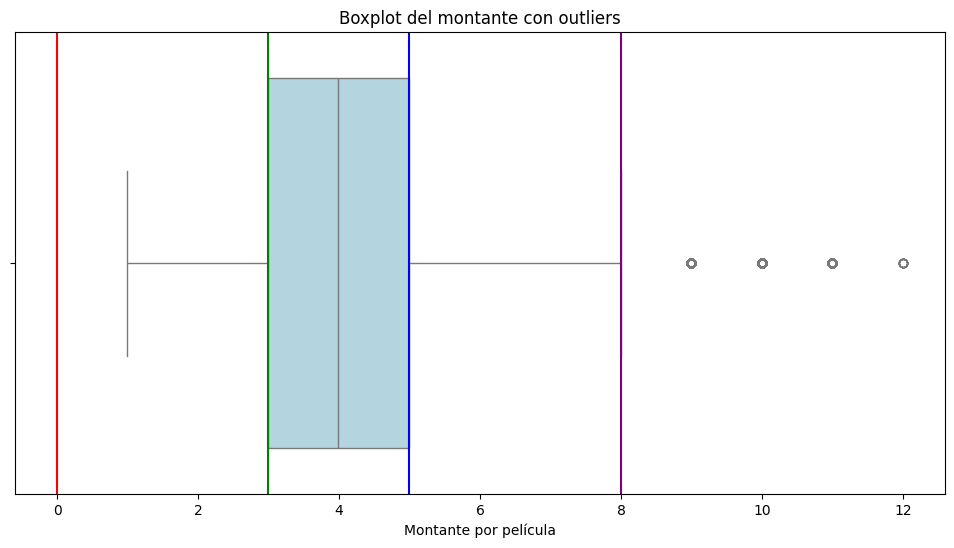

In [2360]:
plt.figure(figsize=(12,6))
# Visualización de outliers en amount
sns.boxplot(x=actividad_clientes_clean_csv['amount'],color='lightblue')
plt.axvline(q1,color='green',label='Q1')
plt.axvline(q3,color='blue',label='Q3')
plt.axvline(lower_bound,color='red',label='Lower bound')
plt.axvline(upper_bound,color='purple',label='Upper bound')

plt.title('Boxplot del montante con outliers')
plt.xlabel('Montante por película')
plt.show()

Se encontraron en la variable **amount** outliers. Tras ajustar el límite inferior a 0 y un límite superior de 7.99 presenta una cantidad de 855 outliers.

El primer cuartil indica que el 25% de los montantes por películas es hasta 2.99. El tercer cuartil muestra que el 75% del montante se situa por debajo de 4.99. Por lo tanto, la mayor concentración de valores se encuentre entre 2.99 y 4.99, que corresponde el rango IQR.

La columna **amount** presenta 4 valores atípicos según el criterio IQR. Esto corresponden a valores que corresponden a películas con montos superiores, pero no se consideran errores de registro. Por tanto, se conservarán para análisis futuros.

A continuación se muestra un gráfico de densidad para visualizar la distribución de **amount** y observar con mayor precisión donde se concentran sus valores

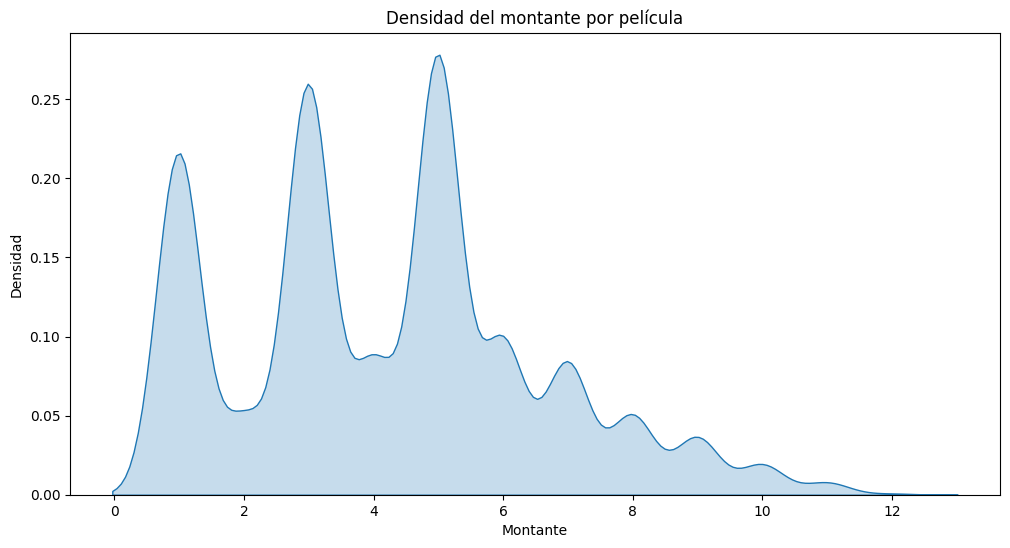

In [2361]:
plt.figure(figsize=(12,6))
sns.kdeplot(actividad_clientes_clean_csv['amount'],fill=True)
plt.title(f'Densidad del montante por película')
plt.xlabel('Montante')
plt.ylabel('Densidad')
plt.show()

En el gráfico de densidad la distribución no es uniforme. Se concentra la mayor parte entre 3 y 5. A partir de ese punto, la densidad disminuye de manera progresiva hasta llegar a montos mas altos donde prácticamente hay pocos montantes elevados.

## 5. Análisis de datos

En esta sección se analizará el dataframe ya depurado y transformado en el apartado anterior,garantizando que el análisis se realice sobre una base fiable y consistente.

### 1. Análisis de la distribución por países de los usuarios

Se generará un mapa mundi utilizando un archivo shapefile que contiene la representación geográfica de los paises. Se mostrará cada país junto con el número total de usuarios únicos, permitiendo visualizar de forma clara la distribución geográfica de los clientes.

In [2362]:
# Descargamos archivo shapefile
mundo = gpd.read_file('../geo/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
#Mostramos los paises del archivo
mundo['NAME']


0                          Fiji
1                      Tanzania
2                     W. Sahara
3                        Canada
4      United States of America
                 ...           
172                      Serbia
173                  Montenegro
174                      Kosovo
175         Trinidad and Tobago
176                    S. Sudan
Name: NAME, Length: 177, dtype: object

Se normaliza los paises para que coincidan con los del dataframe

In [2363]:
mundo['NAME'] = mundo['NAME'].astype('string').str.title().str.strip().str.lower()
mundo['NAME']

0                          fiji
1                      tanzania
2                     w. sahara
3                        canada
4      united states of america
                 ...           
172                      serbia
173                  montenegro
174                      kosovo
175         trinidad and tobago
176                    s. sudan
Name: NAME, Length: 177, dtype: string

Lista ordenada de paises por número de clientes únicos de dicho país

In [2364]:
paises_clientes_unicos = actividad_clientes_clean_csv.groupby('country',as_index=False)['customer_name'].nunique().rename(columns={'customer_name':'usuarios_unicos'}).sort_values('usuarios_unicos',ascending=False)
paises_clientes_unicos

,country,usuarios_unicos
42,india,60
21,china,53
101,united states,36
48,japan,31
58,mexico,30
...,...,...
94,tunisia,1
96,turkmenistan,1
97,tuvalu,1
104,"virgin islands, u.s.",1


Se combinará el dataframe correspondiente al mapa del mundo con nuestro dataframe para identificar que paises coinciden y poder representar correctamente la información en el mapa.

In [2365]:
union = mundo.merge(paises_clientes_unicos,left_on='NAME',right_on='country',how='left')
union[['NAME', 'usuarios_unicos']].head()


,NAME,usuarios_unicos
0,fiji,NaN
1,tanzania,3.0
2,w. sahara,NaN
3,canada,5.0
4,united states of america,NaN


Se observa un error en la tabla anterior, ya que **united states of america** no aparece con usuarios únicos asignados tras la unión con el archivo shp.Se procederá a la normalización de nuestro dataframe, garantizando una unión adecuada y queden asignados los usuarios asociados a su país correctamente.

In [2366]:
# Cálculo de cantidad de paises en cada df
paises_df = set(paises_clientes_unicos['country'])
paises_mapa = set(mundo['NAME'])

sin_coincidencia = sorted(paises_df-paises_mapa)
# Muestra paises que no se encuentran en el df del mundo
sin_coincidencia



['american samoa',
 'anguilla',
 'bahrain',
 'congo, the democratic republic of the',
 'czech republic',
 'dominican republic',
 'faroe islands',
 'french guiana',
 'french polynesia',
 'holy see (vatican city state)',
 'hong kong',
 'kazakstan',
 'liechtenstein',
 'nauru',
 'russian federation',
 'réunion',
 'saint vincent and the grenadines',
 'tonga',
 'tuvalu',
 'united states',
 'virgin islands, u.s.',
 'yugoslavia']

In [2367]:
mundo_paises = sorted(mundo['NAME'])
mundo_paises

['afghanistan',
 'albania',
 'algeria',
 'angola',
 'antarctica',
 'argentina',
 'armenia',
 'australia',
 'austria',
 'azerbaijan',
 'bahamas',
 'bangladesh',
 'belarus',
 'belgium',
 'belize',
 'benin',
 'bhutan',
 'bolivia',
 'bosnia and herz.',
 'botswana',
 'brazil',
 'brunei',
 'bulgaria',
 'burkina faso',
 'burundi',
 'cambodia',
 'cameroon',
 'canada',
 'central african rep.',
 'chad',
 'chile',
 'china',
 'colombia',
 'congo',
 'costa rica',
 'croatia',
 'cuba',
 'cyprus',
 'czechia',
 "côte d'ivoire",
 'dem. rep. congo',
 'denmark',
 'djibouti',
 'dominican rep.',
 'ecuador',
 'egypt',
 'el salvador',
 'eq. guinea',
 'eritrea',
 'estonia',
 'eswatini',
 'ethiopia',
 'falkland is.',
 'fiji',
 'finland',
 'fr. s. antarctic lands',
 'france',
 'gabon',
 'gambia',
 'georgia',
 'germany',
 'ghana',
 'greece',
 'greenland',
 'guatemala',
 'guinea',
 'guinea-bissau',
 'guyana',
 'haiti',
 'honduras',
 'hungary',
 'iceland',
 'india',
 'indonesia',
 'iran',
 'iraq',
 'ireland',
 'isr

En este caso el origen del problema no está en el shapefile, si no en los datos del dataset. Algunos usuarios estan asociados a paises cuya denominación es antigua o ya no existen en la actualidad(PE:yugoslavia). Se procederá al cambio de denominación de paises que si se encuentren en el archivo shapefile. Esta modificación afectará exclusivamente a la visualización del mapa y no alterará los análisis posteriores, ya que únicamente se ajustará los nombres con el fin de permitir la coincidencia entre ambos archivos

Primero se mostrará la cantidad de usuarios únicos en dichos paises.

In [2368]:
# Uso de función isin() que filtra filas comprobando si el valor dde la columna se encuentra dentro de la lista 'sin_coincidencia'
paises_clientes_unicos[paises_clientes_unicos['country'].isin(sin_coincidencia)]

,country,usuarios_unicos
101,united states,36
77,russian federation,28
25,dominican republic,3
106,yugoslavia,2
49,kazakstan,2
23,"congo, the democratic republic of the",2
34,french polynesia,2
2,american samoa,1
24,czech republic,1
4,anguilla,1


Los paises más relevantes **united state** y **russia federation**, ya que concentran un volumen de usuarios únicos. La ausencia de estos valores distorsiona la visión global del mapa, afectando de forma significativa a la visualización que se pretenden obtener. Para solucionarlo, se procederá a ajustar la denominación de aquellos países cuyos nombres puedan ser renombrados con el archivo .shp.

In [2369]:
# Corrección de paises
correccion_paises = {
    'united states' : 'united states of america',
    'congo, the democratic republic of the' : 'dem. rep. congo',
    'czech republic' : 'czechia',
    'dominican republic' : 'dominican rep.',
    'kazakstan' : 'kazakhstan',
    'russian federation' : 'russia'
}

# Se apliaca esta corrección en la columna 'country' del df limpio
actividad_clientes_clean_csv['country'] = actividad_clientes_clean_csv['country'].replace(correccion_paises)

# Se vuelve a obtener los paises(ya normalizados correctamente) por clientes únicos
paises_clientes_unicos = actividad_clientes_clean_csv.groupby('country',as_index=False)['customer_name'].nunique().rename(columns={'customer_name':'usuarios_unicos'}).sort_values('usuarios_unicos',ascending=False)
union = mundo.merge(paises_clientes_unicos,left_on='NAME',right_on='country',how='left')


Mapa del mundo

<Figure size 2000x2000 with 0 Axes>

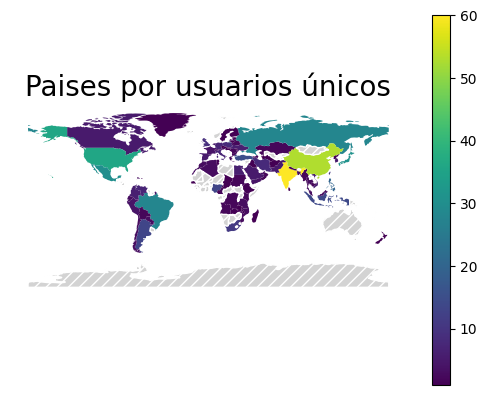

In [2370]:
plt.figure(figsize=(20,20))
union.plot(column='usuarios_unicos',cmap='viridis',legend=True,
           missing_kwds={'color':'lightgrey','label':'no data available','hatch':'///','edgecolor':'white'}
           )
plt.title('Paises por usuarios únicos',fontsize=20)
plt.axis('off')
plt.show()

Top 10 de países por clientes únicos

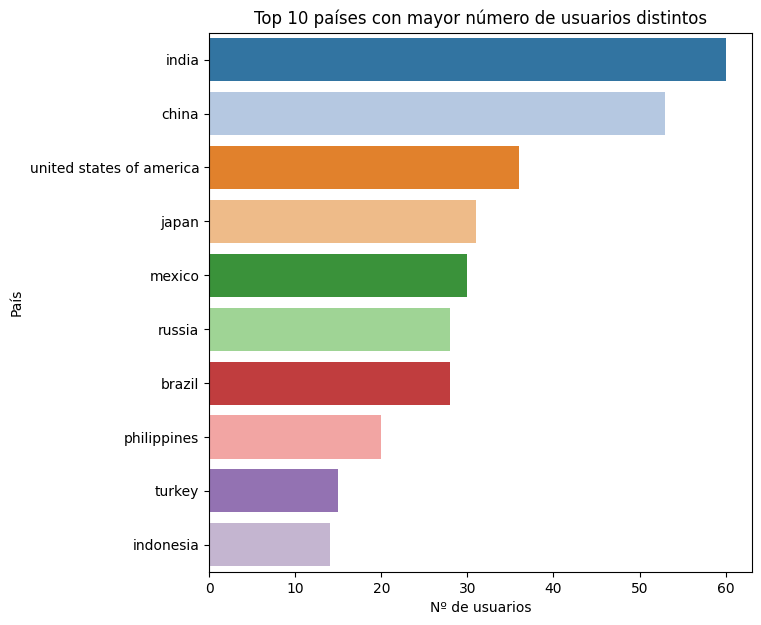

In [2371]:
top = paises_clientes_unicos.head(10)
plt.figure(figsize=(7,7))
sns.barplot(x='usuarios_unicos',y='country',hue='country',data=top,palette='tab20')
plt.title('Top 10 países con mayor número de usuarios distintos')
plt.ylabel('País')
plt.xlabel('Nº de usuarios')
plt.show()

**Conclusion:** Los países mas poblados son los países donde mayoritariamente hay más usuarios únicos. Existe una relación directa entre el tamaño demográfico del país con la cantidad de usuarios únicos por país. 

### 2. Análisis del montante medio por país

Se calculará el promedio del montante por país para identificar que países o regiones presentan un gasto medio más elevado y analizar posibles diferencias en el apartado económico

Primero obtenemos un resumen estadístico de la columna **amount**

In [2372]:
actividad_clientes_clean_csv['amount'].describe()

count    15861.000000
mean         4.217161
std          2.360383
min          0.990000
25%          2.990000
50%          3.990000
75%          4.990000
max         11.990000
Name: amount, dtype: float64

Como vimos anteriormente, en la busqueda outliers los valores correspondiente al 25%,50% y 75% corresponde a una distribución bastante equilibrada. Presenta un valos mínimo de 0.99 y un valor maximo de 11.99. Además el valor medio corresponde con un 4.21 y una desviación estandar de 2.36, esto útltimo indica una variabilidad moderada en los importes abonados por usuarios.

In [2373]:
# Cálculo promedio por país

media_pais = actividad_clientes_clean_csv.groupby('country',as_index=False).agg(
    media_amount=('amount','mean'),
    usuarios_unicos=('customer_name','nunique')
    ).sort_values('media_amount',ascending=False)
media_pais


,country,media_amount,usuarios_unicos
64,nepal,5.308182,1
96,turkmenistan,5.143846,1
6,armenia,4.823333,1
63,nauru,4.796452,1
40,hong kong,4.756667,1
...,...,...,...
94,tunisia,3.535455,1
82,slovakia,3.451538,1
14,brunei,3.195882,1
4,anguilla,3.047143,1


Se observa que algunos países presentan una media elevada.Sin embargo, estos valores no son representativos ya que en dichos paises existe únicamente un usuario único. Por tanto, se procederá a calcular le mediana por país, ofreciendo un análisis mas robusto. A parte, se estudiará con paises que tengan 5 usuarios unicos o más.

In [2374]:
mediana_pais = actividad_clientes_clean_csv.groupby('country',as_index=False).agg(
    mediana_amount=('amount','median'),
    usuarios_unicos=('customer_name','nunique')
    ).sort_values('mediana_amount',ascending=False)
mediana_pais = mediana_pais[mediana_pais['usuarios_unicos']>=5]
mediana_pais

,country,mediana_amount,usuarios_unicos
18,canada,4.99,5
67,nigeria,4.99,13
80,saudi arabia,4.99,5
103,vietnam,4.99,6
85,spain,4.99,5
95,turkey,4.99,15
65,netherlands,4.99,5
13,brazil,4.99,28
47,italy,4.99,7
22,colombia,4.49,6


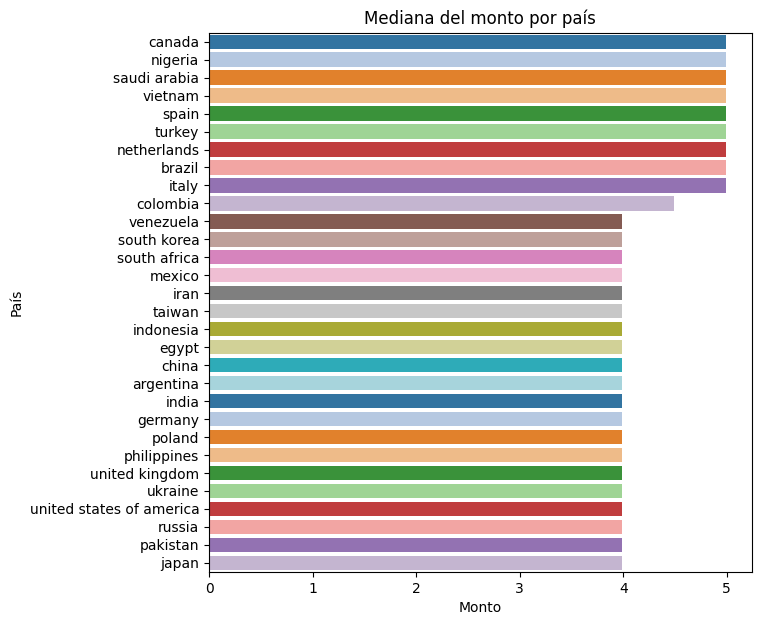

In [2375]:
plt.figure(figsize=(7,7))
sns.barplot(x='mediana_amount',y='country',hue='country',data=mediana_pais,palette='tab20')
plt.title('Mediana del monto por país')
plt.ylabel('País')
plt.xlabel('Monto')
plt.show()

**Conclusión:** No necesariamente los países con mayor número de usuarios únicos son también los que presentan un montante medio más elevado en los alquileres. Solo del top 10 de países con mas usuarios únicos, se observa que solo Brasil aparece simultáneamente entre los países con mayor gasto medio. Esto implica que el comportamiento económico de los clientes varía significativamente entre regiones.

### 3. Análisis de la duración media de entrega de peliculas desde que se alquila hasta que se devuelve por país

En este apartado se analizará la duración media de los alquileres por país, con el objetivo de identificar diferencias en los tiempos de devolución y detectar posibles patrones geográficos en el comportamiento de los usuarios

Antes de calcular la duración media de los alquileres, se visualizará la distribución temporal de las fecha en las que se realizaron los alquileres. Se buscará encontrar picos de demanda para comprender mejor el comportamiento de los usuarios.

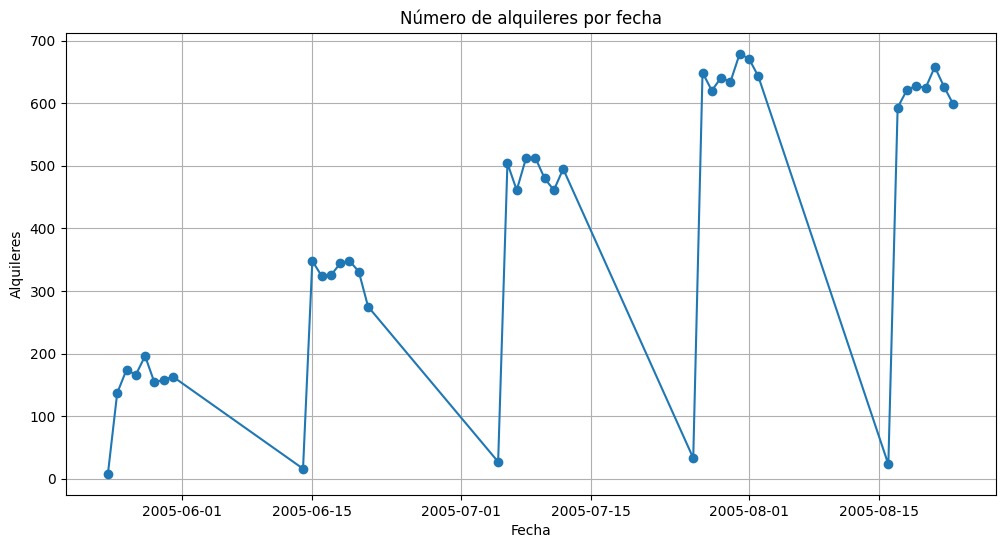

In [2376]:
#Copia para no modificar el df limpio
df_cop_rental_day = actividad_clientes_clean_csv.copy()
# Extraer solo la fecha sin hora
df_cop_rental_day['rental_day'] = df_cop_rental_day['rental_date'].dt.date

# Agrupar por día
alquileres = (
    df_cop_rental_day
    .groupby('rental_day')
    .size()
    .reset_index(name='cantidad_alquileres')
)

plt.figure(figsize=(12,6))
plt.plot(alquileres['rental_day'],alquileres['cantidad_alquileres'],marker='o')
plt.title('Número de alquileres por fecha')
plt.xlabel('Fecha')
plt.ylabel('Alquileres')
plt.grid(True)
plt.show()


Esas caidas que se muestran se debe a que hay días sin alquileres registrados por lo que se producen esas caidas y saltos tan enormes

Ahora se mostrarán las devoluciones

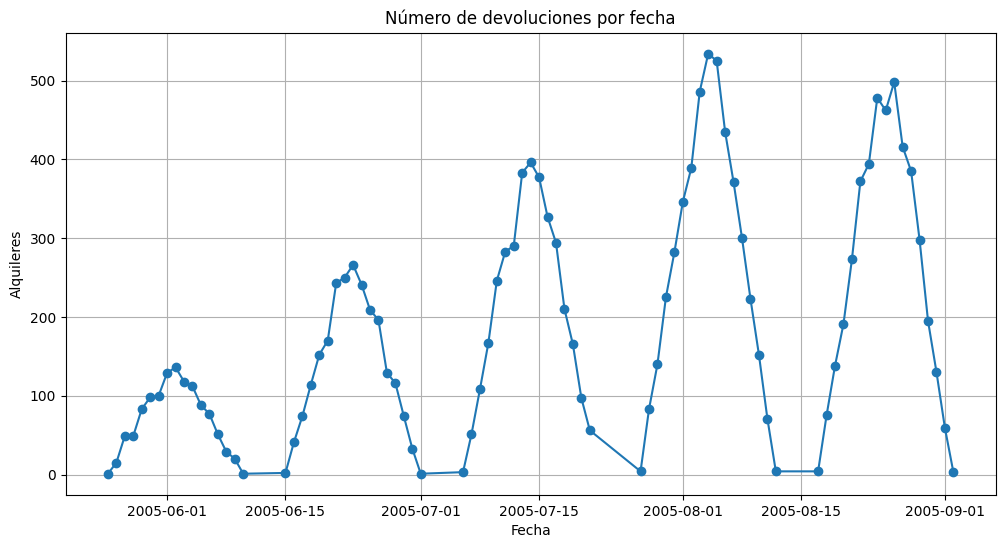

In [2377]:
#Copia para no modificar el df limpio
df_cop_rental_day = actividad_clientes_clean_csv.copy()
# Extraer solo la fecha sin hora
df_cop_rental_day['rental_day'] = df_cop_rental_day['return_date'].dt.date

# Agrupar por día
alquileres = (
    df_cop_rental_day
    .groupby('rental_day')
    .size()
    .reset_index(name='cantidad_alquileres')
)

plt.figure(figsize=(12,6))
plt.plot(alquileres['rental_day'],alquileres['cantidad_alquileres'],marker='o')
plt.title('Número de devoluciones por fecha')
plt.xlabel('Fecha')
plt.ylabel('Alquileres')
plt.grid(True)
plt.show()

Ocurre lo mismo que en los alquileres por falta de registros.

Ahora se procederá al cálculo de medio por país de tiempo alquilado, con el objetivo de comparar el tiempo que los usuarios mantienen las películas antes de devolverlas y analizar si existen diferencias significativas entre regiones. Se analizará con un mínimo de 5 usuarios unicos por país como anteriormente

In [2378]:
mediana_dias_alquilados = actividad_clientes_clean_csv.groupby('country',as_index=False).agg(
    mediana_dias_alquilados =('rental_duration','median'),
    usuarios_unicos=('customer_name','nunique')
    ).sort_values('mediana_dias_alquilados',ascending=False)
mediana_dias_alquilados = mediana_dias_alquilados[mediana_dias_alquilados['usuarios_unicos']>=5]
mediana_dias_alquilados 

,country,mediana_dias_alquilados,usuarios_unicos
74,poland,6.0,8
98,ukraine,6.0,6
103,vietnam,6.0,6
84,south korea,6.0,5
36,germany,5.0,7
27,egypt,5.0,6
42,india,5.0,60
5,argentina,5.0,13
13,brazil,5.0,28
18,canada,5.0,5


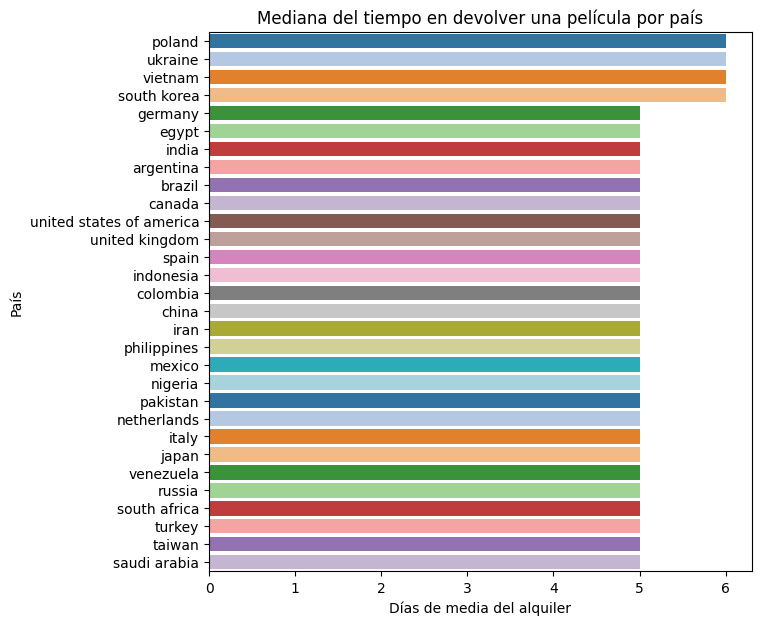

In [2379]:
plt.figure(figsize=(7,7))
sns.barplot(x='mediana_dias_alquilados',y='country',hue='country',data=mediana_dias_alquilados,palette='tab20')
plt.title('Mediana del tiempo en devolver una película por país')
plt.ylabel('País')
plt.xlabel('Días de media del alquiler')
plt.show()

**Conclusión:** La duración media del alquiler se sitúa aproximadamente entre los 5 y 6 días en los países que cuentan con 5 y o mas usuarios únicos. Esto indica un patrón bastante homogéneo entre estas regiones.

### 4. Otros análisis

Se llevará a cabo otros anális gráficos adicionales para explorar aspectos del dataset no abordado anteriormente.

Top 10 usuarios que mas han gastado

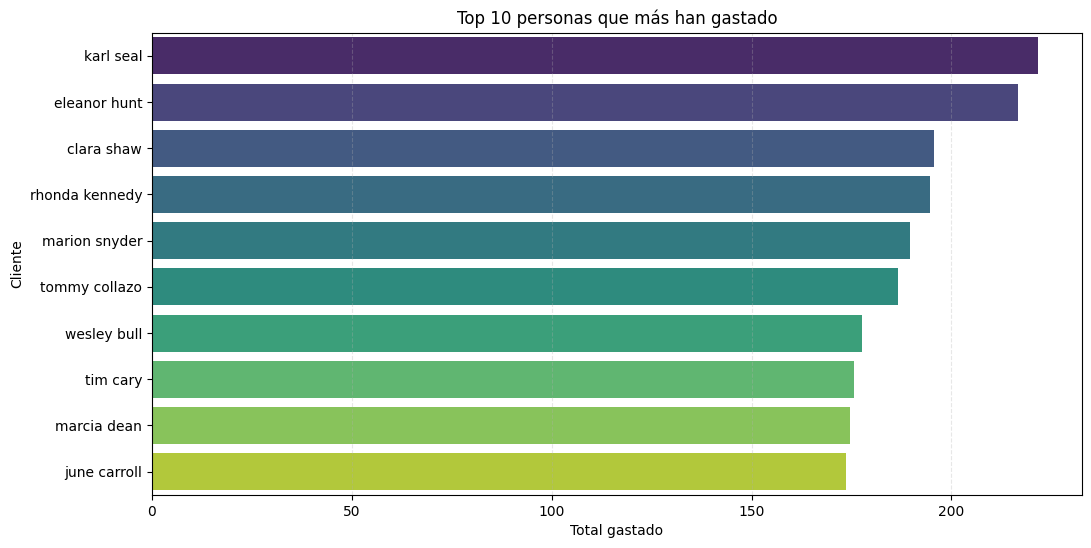

In [2380]:
gasto_por_usuario = (
    actividad_clientes_clean_csv.groupby('customer_name',as_index=False)['amount'].sum().rename(columns={'amount':'total_gastado'}).sort_values('total_gastado',ascending=False).head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=gasto_por_usuario,
    x='total_gastado',
    y='customer_name',
    hue='customer_name',
    palette='viridis'
)
plt.title('Top 10 personas que más han gastado')
plt.xlabel('Total gastado')
plt.ylabel('Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Top 5 países con mas amount

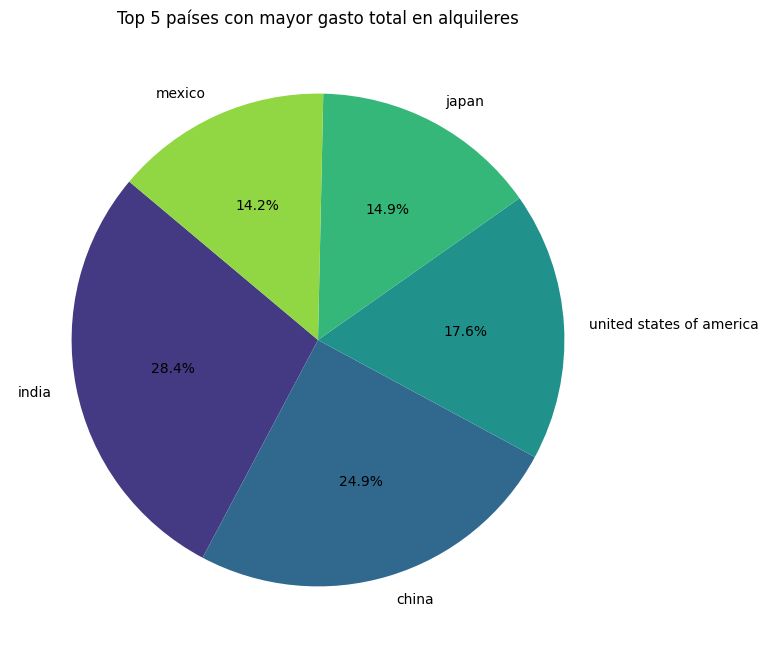

In [2381]:
gasto_por_pais = (
    actividad_clientes_clean_csv.groupby('country',as_index=False)['amount'].sum().rename(columns={'amount':'total_gastado'}).sort_values('total_gastado',ascending=False).head()
)
plt.figure(figsize=(8,8))
plt.pie(
    gasto_por_pais['total_gastado'],
    labels=gasto_por_pais['country'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', 5)
)
plt.title('Top 5 países con mayor gasto total en alquileres')
plt.show()


El gasto total por país en el top 5 coincide con aquellos países que cuentan con un mayor número de usuarios únicos. Es lógico, ya que cuanto mayor volumen de usuarios únicos, mayor será el gasto acumulado.

## 6. Exportación del dataframe limpio

In [2382]:
actividad_clientes_clean_csv.to_csv('../csv_files/actividad_clientes_clean.csv')